In [5]:
# I have a txt file, and inside the txt file, there are some lines of text. each line of text is a json list.
# and in that list are some unique strings. I want to train an LSTM model to predict the nexts string in the list given the previous strings.
# I will use the first 80% of the strings to train the model and the last 20% to test the model.
# I will use the model to predict the nexts string in the list given the previous strings.
# I will use the model to generate a new list of strings.
# use pytorch
# use gpu
# do all in one cell

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
from sklearn.model_selection import train_test_split

# Check if CUDA is available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class FunctionCallDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index].to(device), self.labels[index].to(device)


def load_data(json_path, history_length=3):
    function_calls = []
    with open(json_path, 'r') as file:
        for line in file:
            function_calls.append(json.loads(line.strip()))

    # only first 5 lines
    validation_data = function_calls[-1]
    function_calls = function_calls[:-1]

    all_functions = set(fn for trace in function_calls for fn in trace)
    func_to_index = {func: i for i, func in enumerate(all_functions)}
    num_classes = len(all_functions)

    # Prepare profiling samples
    data, labels = [], []
    for call_list in function_calls:
        indexed_calls = [func_to_index[func] for func in call_list]
        for i in range(len(indexed_calls) - history_length):
            data.append(torch.tensor(indexed_calls[i:i + history_length], dtype=torch.long))
            labels.append(torch.tensor(indexed_calls[i + history_length], dtype=torch.long))

    return data, labels, num_classes, validation_data, func_to_index



class LSTMModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=64, hidden_dim=128):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        output = self.fc(lstm_out[:, -1, :])
        return output


def train(train_loader, num_epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for sequences, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        average_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{num_epochs}, Average Loss: {average_loss:.6f}")

    # move the model to cpu before saving
    model.to('cpu')
    # save the model
    torch.save(model.state_dict(), 'lstm_model.pth')
    print("Model saved successfully.")


def evaluate(test_loader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in test_loader:
            outputs = model(sequences)
            _, predicted = torch.max(outputs.profile, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")


window_sizes = [1, 2, 5, 10, 20, 50, 100]
for window_size in window_sizes:
    torch.cuda.empty_cache()

    print(f"Window Size: {window_size}")

    json_path = '/truejit/evaluation/prediction-accuracy/profiling/502.gcc_r.json'
    data, labels, num_classes, validation_data, func_to_index = load_data(json_path, history_length=window_size)
    # print(f"Number of unique functions: {num_classes}")
    # print(f"Number of profiling samples: {len(profiling)}")
    # print(f"Number of validation samples: {len(validation_data)}")

    # Splitting the profiling
    train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.20, random_state=42)
    train_dataset = FunctionCallDataset(train_data, train_labels)
    test_dataset = FunctionCallDataset(test_data, test_labels)
    print(f"Number of training samples: {len(train_dataset)}")
    print(f"Number of test samples: {len(test_dataset)}")

    # Creating dataloaders
    batch_size = 4096  # adjust this to fit in the gpu memory
    # for window_size=3 --> 128 * 100 was good
    # for window_size=30 --> 128 * 80 is good
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    print("Dataloaders created successfully.")

    model = LSTMModel(num_classes).to(device)

    train(train_loader, num_epochs=10)

    model = LSTMModel(num_classes)
    model.load_state_dict(torch.load('lstm_model.pth'))

    evaluate(test_loader)


Using device: cpu
Window Size: 1


KeyboardInterrupt: 

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
from sklearn.model_selection import train_test_split

# Check if CUDA is available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [8]:
# clear up the gpu memory
torch.cuda.empty_cache()

In [9]:
class FunctionCallDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index].to(device), self.labels[index].to(device)

In [10]:
def load_data(json_path, history_length=3):
    function_calls = []
    with open(json_path, 'r') as file:
        for line in file:
            function_calls.append(json.loads(line.strip()))

    # only first 5 lines
    validation_data = function_calls[-1]
    function_calls = function_calls[:-1]

    all_functions = set(fn for trace in function_calls for fn in trace)
    func_to_index = {func: i for i, func in enumerate(all_functions)}
    num_classes = len(all_functions)

    # Prepare profiling samples
    data, labels = [], []
    for call_list in function_calls:
        indexed_calls = [func_to_index[func] for func in call_list]
        for i in range(len(indexed_calls) - history_length):
            data.append(torch.tensor(indexed_calls[i:i + history_length], dtype=torch.long))
            labels.append(torch.tensor(indexed_calls[i + history_length], dtype=torch.long))

    return data, labels, num_classes, validation_data, func_to_index


json_path = '/truejit/evaluation/prediction-accuracy/profiling/502.gcc_r.json'
data, labels, num_classes, validation_data, func_to_index = load_data(json_path, history_length=5)
print(f"Number of unique functions: {num_classes}")
print(f"Number of profiling samples: {len(data)}")
print(f"Number of validation samples: {len(validation_data)}")

Number of unique functions: 9937
Number of data samples: 1233321
Number of validation samples: 8224


In [11]:
# Splitting the profiling
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.20, random_state=42)
train_dataset = FunctionCallDataset(train_data, train_labels)
test_dataset = FunctionCallDataset(test_data, test_labels)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 986656
Number of test samples: 246665


In [12]:
# Creating dataloaders
train_loader = DataLoader(train_dataset, batch_size=128 * 400, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128 * 400, shuffle=False)
print("Dataloaders created successfully.")

Dataloaders created successfully.


In [13]:
# split training and evaluation into separate functions
class LSTMModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=64, hidden_dim=128):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        output = self.fc(lstm_out[:, -1, :])
        return output


model = LSTMModel(num_classes).to(device)
model

LSTMModel(
  (embedding): Embedding(9937, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=9937, bias=True)
)

In [14]:
def train(train_loader, num_epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for sequences, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        average_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{num_epochs}, Average Loss: {average_loss:.6f}")

    # move the model to cpu before saving
    model.to('cpu')
    # save the model
    torch.save(model.state_dict(), 'lstm_model.pth')
    print("Model saved successfully.")


train(train_loader, num_epochs=25)

Epoch 1/25, Average Loss: 5.846209
Epoch 2/25, Average Loss: 1.109331
Epoch 3/25, Average Loss: 0.539106
Epoch 4/25, Average Loss: 0.388071
Epoch 5/25, Average Loss: 0.321512
Epoch 6/25, Average Loss: 0.281531
Epoch 7/25, Average Loss: 0.253774
Epoch 8/25, Average Loss: 0.233522
Epoch 9/25, Average Loss: 0.218130
Epoch 10/25, Average Loss: 0.205057
Epoch 11/25, Average Loss: 0.195275
Epoch 12/25, Average Loss: 0.185960
Epoch 13/25, Average Loss: 0.178581
Epoch 14/25, Average Loss: 0.173065
Epoch 15/25, Average Loss: 0.168521
Epoch 16/25, Average Loss: 0.163744
Epoch 17/25, Average Loss: 0.159604
Epoch 18/25, Average Loss: 0.156296
Epoch 19/25, Average Loss: 0.153637
Epoch 20/25, Average Loss: 0.150691
Epoch 21/25, Average Loss: 0.148580
Epoch 22/25, Average Loss: 0.146357
Epoch 23/25, Average Loss: 0.144883
Epoch 24/25, Average Loss: 0.143057
Epoch 25/25, Average Loss: 0.142625
Model saved successfully.


In [ ]:
# load the model
model = LSTMModel(num_classes)
model.load_state_dict(torch.load('lstm_model.pth'))

In [15]:
def evaluate(test_loader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in test_loader:
            outputs = model(sequences)
            _, predicted = torch.max(outputs.profile, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")


evaluate(test_loader)

Validation Accuracy: 93.39%


In [16]:
prediction_cache = {}
model.to('cpu')

LSTMModel(
  (embedding): Embedding(9937, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=9937, bias=True)
)

In [17]:
import sys


def predict_next_function(history):
    history = [func_to_index[fn] for fn in history]
    history = tuple(history)
    if history in prediction_cache:
        # print("+", end="")
        return prediction_cache[history]

    model.eval()
    with torch.no_grad():
        output = model(torch.tensor(history, dtype=torch.long).unsqueeze(0))
        _, predicted = torch.max(output.profile, 1)
        predicted_func = list(func_to_index.keys())[list(func_to_index.values()).index(predicted.item())]
        prediction_cache[history] = predicted_func
        # print("-", end="")
        return predicted_func

In [18]:
# warm up the prediction cache
for i in range(0, len(validation_data)):
    predict_next_function(validation_data[i:i + 5])

In [19]:
def predict_next_n_functions(history, n):
    next_n_funcs = []
    for _ in range(n):
        next_func = predict_next_function(history)
        next_n_funcs.append(next_func)
        history = history[1:] + [next_func]
    return next_n_funcs

In [20]:
predict_next_function(validation_data[:5]), validation_data[5]

('<__cxa_atexit@plt>', '<__cxa_atexit@plt>')

In [21]:
# for all the 3-sequence in the validation profiling, predict the nexts n functions, and compare with the actual nexts n functions and calculate the accuracy
# for window_size in [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]:
for window_size in range(1, 100):
    scores = []
    for i in range(len(validation_data) - window_size):
        next_n_funcs = predict_next_n_functions(validation_data[i:i + 5], n=window_size)
        # print(next_n_funcs)
        to_set = set(next_n_funcs)
        actual_next_n_funcs = validation_data[i + 5:i + 5 + window_size]
        # print(actual_next_n_funcs)
        scores.append(len(to_set.intersection(actual_next_n_funcs)) / window_size)
        # print(scores)

    accuracy = 100 * sum(scores) / len(scores)
    print(f"Prediction Accuracy for next {window_size} functions: {accuracy:.2f}%")

Prediction Accuracy for next 1 functions: 95.37%
Prediction Accuracy for next 2 functions: 94.08%
Prediction Accuracy for next 3 functions: 92.91%
Prediction Accuracy for next 4 functions: 91.86%
Prediction Accuracy for next 5 functions: 90.90%
Prediction Accuracy for next 6 functions: 90.01%
Prediction Accuracy for next 7 functions: 89.18%
Prediction Accuracy for next 8 functions: 88.40%
Prediction Accuracy for next 9 functions: 87.65%
Prediction Accuracy for next 10 functions: 86.92%
Prediction Accuracy for next 11 functions: 86.22%
Prediction Accuracy for next 12 functions: 85.53%
Prediction Accuracy for next 13 functions: 84.86%
Prediction Accuracy for next 14 functions: 84.22%
Prediction Accuracy for next 15 functions: 83.60%
Prediction Accuracy for next 16 functions: 82.99%
Prediction Accuracy for next 17 functions: 82.41%
Prediction Accuracy for next 18 functions: 81.85%
Prediction Accuracy for next 19 functions: 81.32%
Prediction Accuracy for next 20 functions: 80.80%
Predictio

In [29]:
# for 100 nexts functions show the accuracy over time
history_length = 5
window_size = 10
scores = []
for i in range(len(validation_data) - window_size):
    next_n_funcs = predict_next_n_functions(validation_data[i:i + history_length], n=window_size)
    # print(next_n_funcs)
    to_set = set(next_n_funcs)
    actual_next_n_funcs = validation_data[i + history_length:i + history_length + window_size]
    # print(actual_next_n_funcs)
    scores.append(len(to_set.intersection(actual_next_n_funcs)) / window_size)

In [30]:
scores = [score * 100 for score in scores]

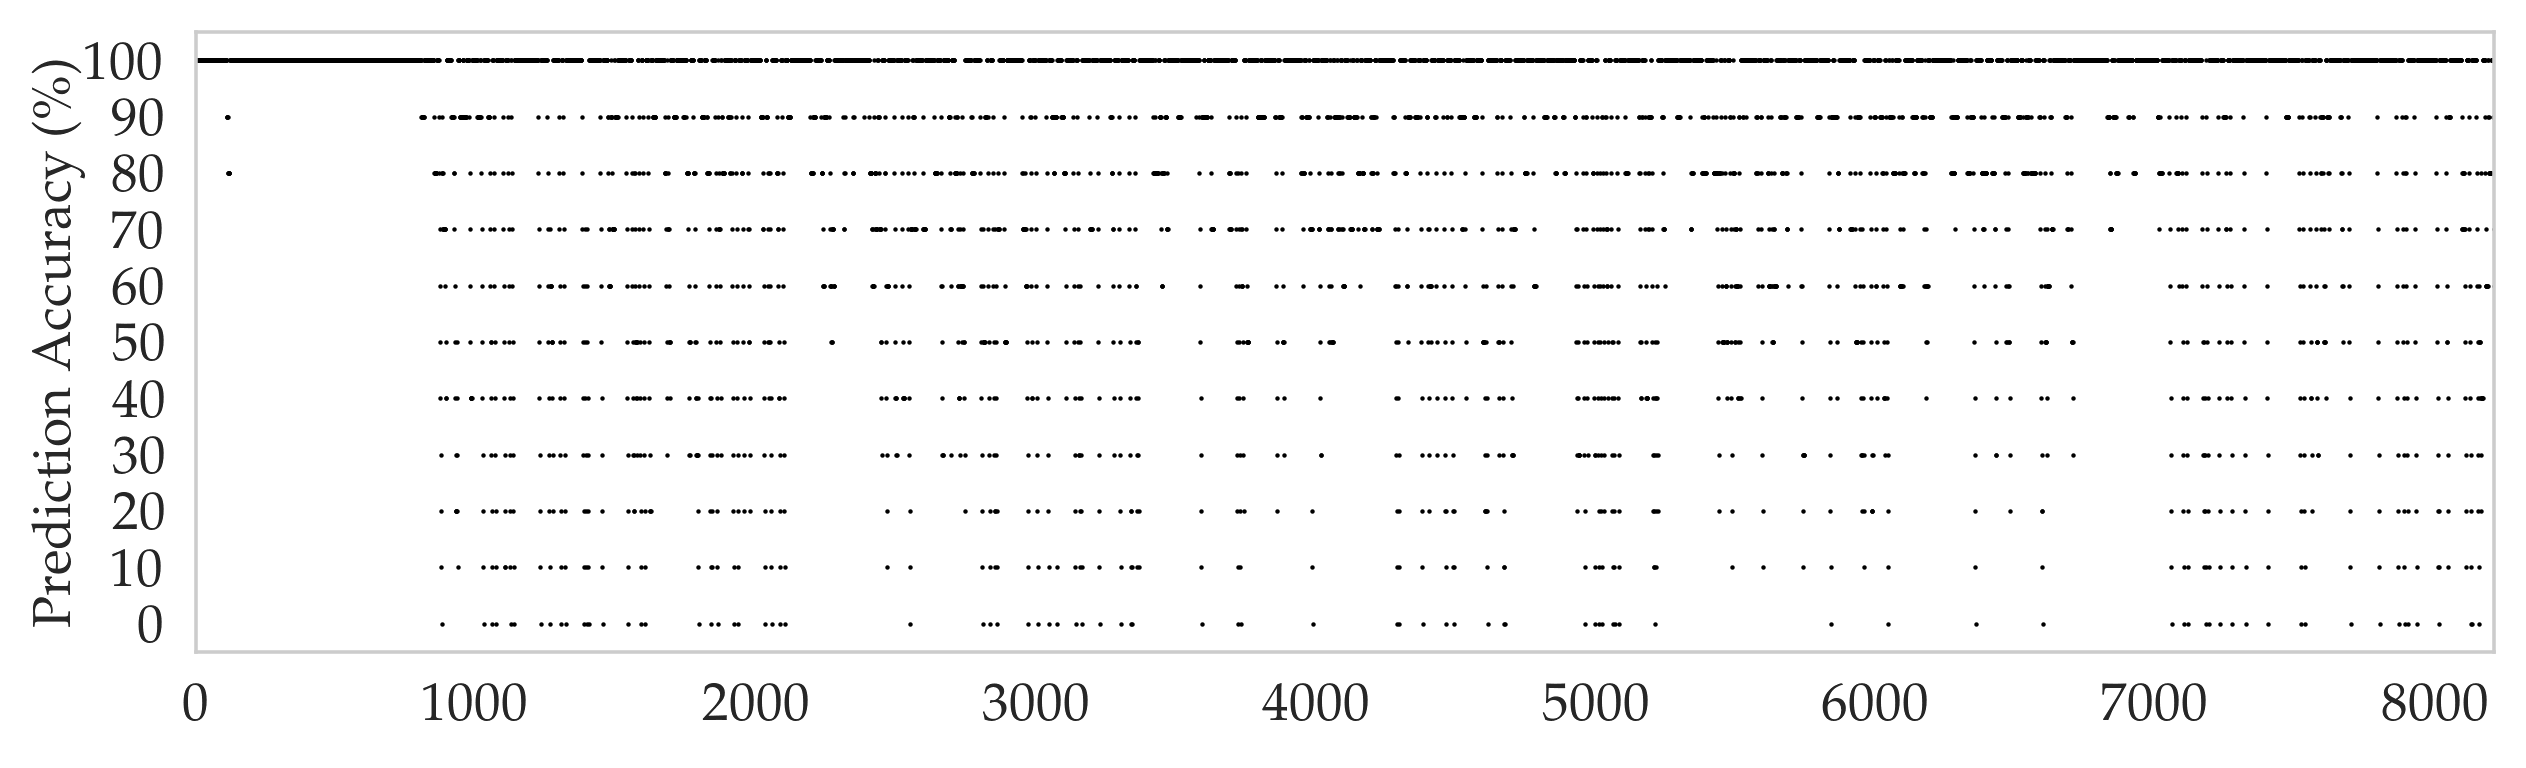

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2.5), dpi=320)
plt.plot(scores, marker='.', color='black', linewidth=0.1, markersize=2, markerfacecolor='black', markeredgewidth=0,
         markeredgecolor='black', linestyle='none')

# plt.xlabel('Functions Timeline')
plt.ylabel('Prediction Accuracy (\%)', labelpad=0, fontsize=12)

plt.xticks(range(0, len(scores), 1000), [str(i) for i in range(0, len(scores), 1000)], fontsize=12)
plt.yticks(range(0, 100 + 1, 10), [str(i) for i in range(0, 100 + 1, 10)], fontsize=12)

plt.ylim(-5, 105)

# no grid
plt.grid(False)

# zero margin
plt.margins(0)

plt.tight_layout()

plt.savefig(f'out/prediction_accuracy_over_time.{window_size}.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01,
            dpi=320)

plt.show()

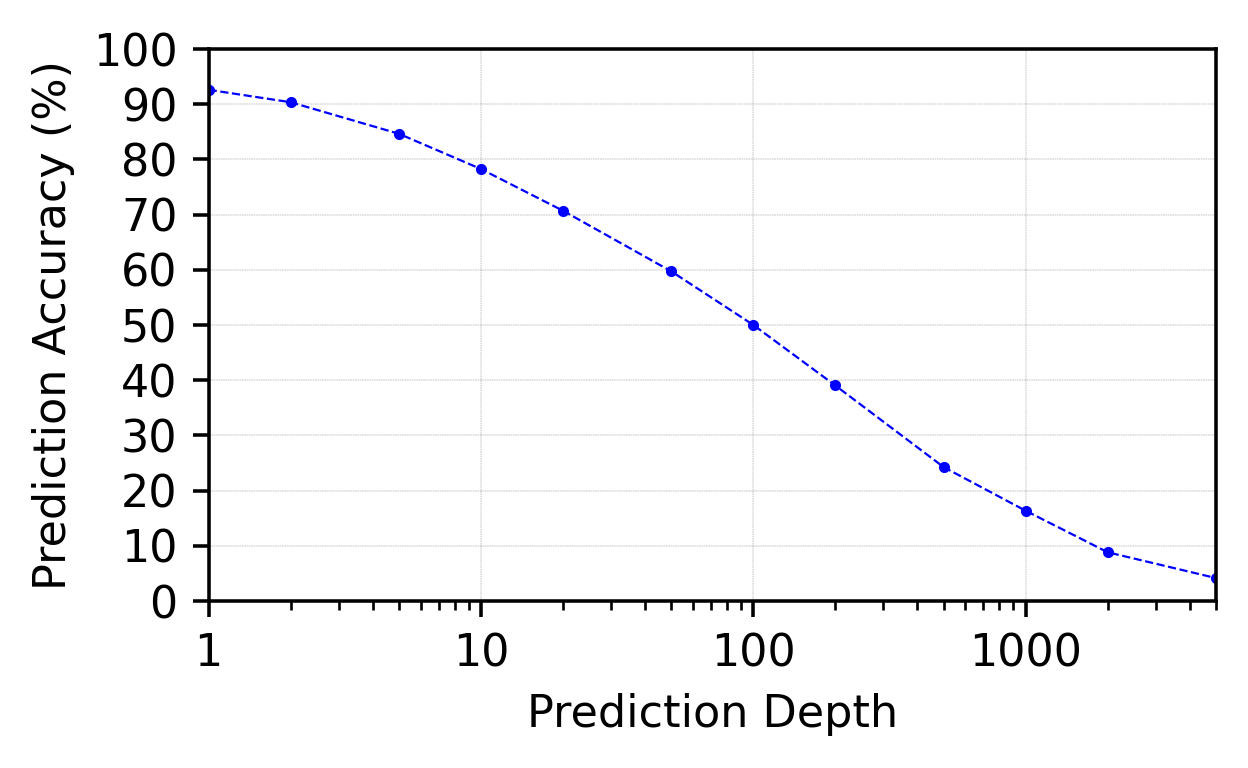

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 2.5), dpi=320)

window_sizes = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
accuracies = [92.61, 90.36, 84.64, 78.26, 70.71, 59.72, 50.02, 39.06, 24.27, 16.37, 8.85, 4.17]

plt.plot(window_sizes, accuracies, marker='.', color='blue', linewidth=0.5, markersize=4, markerfacecolor='blue',
         markeredgewidth=0.5, markeredgecolor='blue', linestyle='--')

plt.xlabel('Prediction Depth')
# x is log scale
plt.xscale('log')
# x ticks are [1, 10, 100, 1000, 10000]
plt.xticks([1, 10, 100, 1000, 10000], ['1', '10', '100', '1000', '10000'])

# xlimit is 1 to 10000
# plt.xlim(1, 10000)

# y-ticks are [0, 20, 40, 60, 80, 100]
plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
           ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100'])

# ylimit is 0 to 100
plt.ylim(0, 100)

# no margin
plt.margins(0)

plt.ylabel('Prediction Accuracy (%)')
# plt.title('Prediction Accuracy vs Prediction Depth')
# major grid lines
plt.grid(color='gray', linestyle='--', linewidth=0.1)

plt.tight_layout()

# topdf
plt.savefig('out/prediction_accuracy_vs_prediction_depth.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01,
            dpi=320)

plt.show()


In [2]:
import json
import matplotlib.pyplot as plt
import scipy.stats.mstats
import numpy as np
import bokeh
import bokeh.palettes

# font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

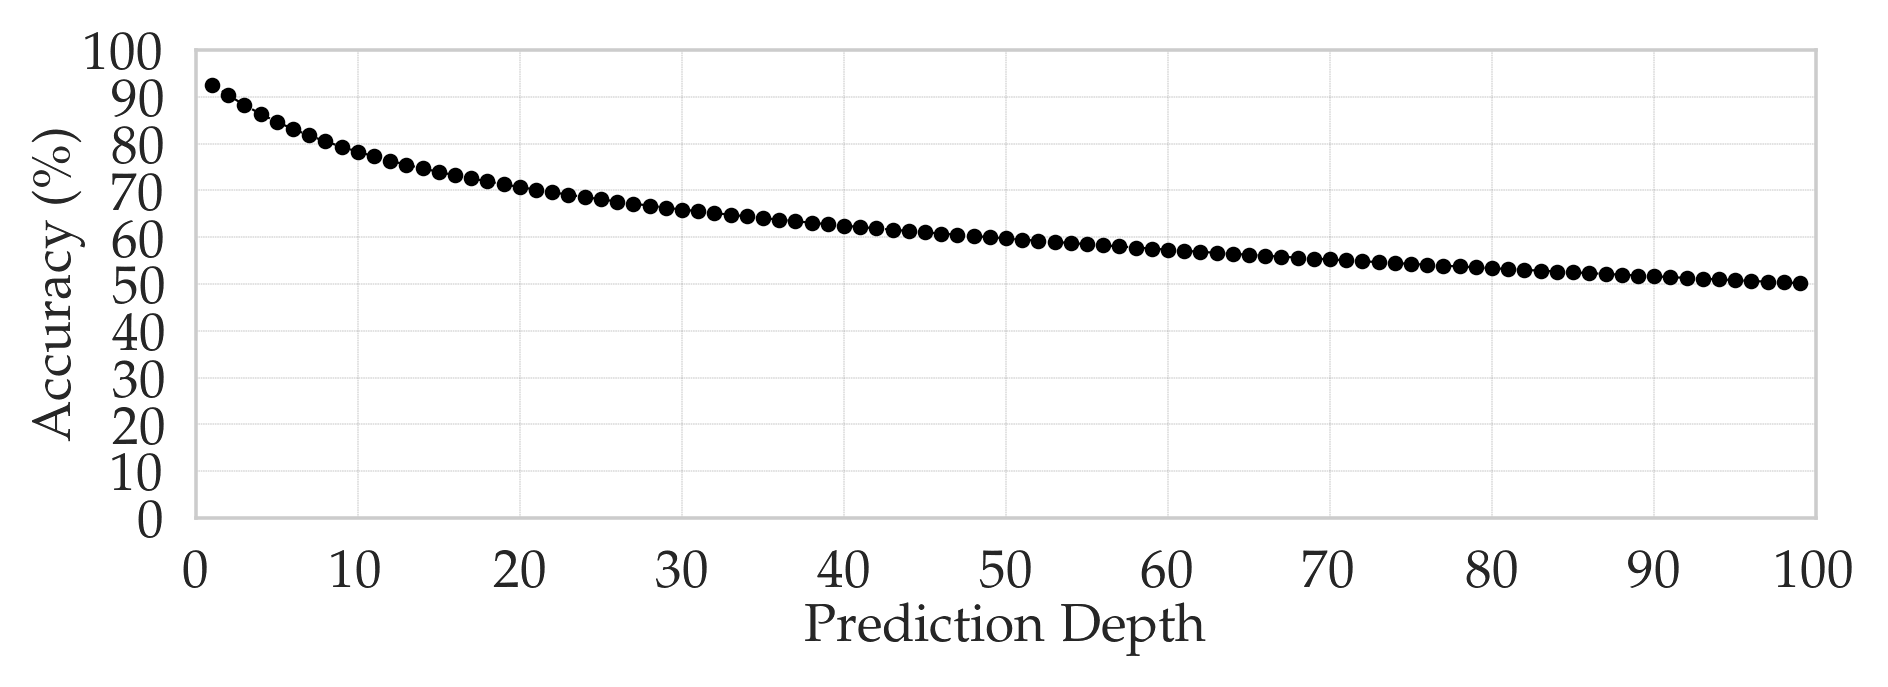

In [7]:
scores = [92.61, 90.36, 88.24, 86.34, 84.64, 83.12, 81.73, 80.47, 79.32, 78.26, 77.26, 76.33, 75.48, 74.69, 73.94,
          73.23, 72.56, 71.92, 71.30, 70.71, 70.15, 69.60, 69.08, 68.58, 68.09, 67.62, 67.16, 66.73, 66.31, 65.91,
          65.53, 65.15, 64.79, 64.43, 64.09, 63.74, 63.41, 63.08, 62.76, 62.45, 62.16, 61.87, 61.59, 61.31, 61.04,
          60.77, 60.50, 60.24, 59.98, 59.72, 59.47, 59.22, 58.98, 58.74, 58.50, 58.26, 58.02, 57.79, 57.55, 57.32,
          57.09, 56.87, 56.65, 56.44, 56.23, 56.03, 55.82, 55.63, 55.43, 55.23, 55.04, 54.85, 54.66, 54.47, 54.28,
          54.10, 53.91, 53.73, 53.55, 53.36, 53.19, 53.01, 52.83, 52.66, 52.48, 52.31, 52.14, 51.97, 51.79, 51.62,
          51.46, 51.29, 51.12, 50.96, 50.80, 50.64, 50.48, 50.33, 50.17]

# plot the scores
width = 6
height = 2.25
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

color = 'black'
ax.plot(range(1, 100), scores, marker='.', color=color
        , linewidth=0.5, markersize=6, markerfacecolor=color,
        markeredgewidth=0.5, markeredgecolor=color, linestyle='--')

plt.xlabel('Prediction Depth', fontsize=12, labelpad=0)

# x ticks are 1 to 100 every 10
plt.xticks(range(0, 100 + 1, 10), [str(i) for i in range(0, 100 + 1, 10)], fontsize=12)

# x lim is 1 to 100
plt.xlim(0, 100)

# y lim is 0 to 100
plt.ylim(0, 100)

# y ticks are 0 to 100 every 10
plt.yticks(range(0, 100 + 1, 10), [str(i) for i in range(0, 100 + 1, 10)], fontsize=12)

plt.ylabel(r'Accuracy (\%)', labelpad=0, fontsize=12)

# major grid lines
plt.grid(color='gray', linestyle='--', linewidth=0.1)



plt.tight_layout()

# topdf
plt.savefig('out/prediction_accuracy_vs_prediction_depth.1-100.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01,
            dpi=320)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# window_sizes = [1, 2, 5, 10, 20]
# accuracies = [77.88, 86.59, 92.96, 95.13, 96.07]
window_sizes = [1, 2, 5, 10, 20, 50, 100]
accuracies = [78.00, 86.72, 92.47, 94.42, 94.91, 95.40, 95.41]

# plt.figure(figsize=(4, 2.5), dpi=320)
width = 6
height = 2.2
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# ax.plot(window_sizes, accuracies, marker='.', color='blue', linewidth=0.5, markersize=4, markerfacecolor='blue',
#          markeredgewidth=0.5, markeredgecolor='blue', linestyle='--')
color = 'black'
ax.plot(window_sizes, accuracies, marker='.', color=color, linewidth=0.5, markersize=8, markerfacecolor=color,
        markeredgewidth=0.5, markeredgecolor=color, linestyle='--')

plt.xlabel('History Size', fontsize=12, labelpad=0)

# x is log
plt.xscale('log')

# x ticks are 1, 2, 5, 10, 20
plt.xticks(window_sizes, [str(i) for i in window_sizes], fontsize=12)

# x lim
plt.xlim(min(window_sizes), max(window_sizes))

# y lim is 0 to 100
plt.ylim(0, 100)

# y ticks are 0 to 100 every 10
plt.yticks(range(0, 100 + 1, 10), [str(i) for i in range(0, 100 + 1, 10)], fontsize=10)

plt.ylabel('Prediction Accuracy (\%)', labelpad=0, fontsize=10)

# major grid lines
plt.grid(color='gray', linestyle='--', linewidth=0.1)

plt.tight_layout()

# topdf
plt.savefig('out/validation_accuracy_vs_history_size.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01, dpi=320)

plt.show()

([tensor(1, dtype=torch.uint16),
  tensor(2, dtype=torch.uint16),
  tensor(3, dtype=torch.uint16),
  tensor(4, dtype=torch.uint16),
  tensor(1, dtype=torch.uint16),
  tensor(2, dtype=torch.uint16),
  tensor(4, dtype=torch.uint16),
  tensor(5, dtype=torch.uint16),
  tensor(1, dtype=torch.uint16),
  tensor(2, dtype=torch.uint16),
  tensor(5, dtype=torch.uint16),
  tensor(6, dtype=torch.uint16)],
 [tensor(2, dtype=torch.uint16),
  tensor(3, dtype=torch.uint16),
  tensor(4, dtype=torch.uint16),
  tensor(5, dtype=torch.uint16),
  tensor(2, dtype=torch.uint16),
  tensor(4, dtype=torch.uint16),
  tensor(5, dtype=torch.uint16),
  tensor(6, dtype=torch.uint16),
  tensor(2, dtype=torch.uint16),
  tensor(5, dtype=torch.uint16),
  tensor(6, dtype=torch.uint16),
  tensor(7, dtype=torch.uint16)])